# 05 - Candidate Screening

## Data sources
- **ML-HydPARK** (Zenodo, v0.0.5): cleaned experimental thermodynamic data for metal hydrides (~770 entries)
- **ElementalH_Ef**: experimental elemental hydride formation energies, used for compositional feature engineering

## Target Variable
- `Hydrogen_Weight_Percent`

## Goals
- Screen metal hydride candidates using the Dataset A model (Random Forest, R²=0.765)
- Identify compounds with predicted wt% H2 above 3.5 wt% (exploratory threshold) and 5.0 wt% (DOE target for near-RT solid-state hydrogen storage)
- Note: desorption temperature screening is not performed as the Dataset B model did not generalise reliably (test RMSE=87°C)

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import chemparse
from sklearn.model_selection import train_test_split


In [2]:
# Import the trained Random Forest model for Dataset A
rf_A = joblib.load('../results/rf_A_model.joblib')
print('Model loaded.')

Model loaded.


In [3]:
# Load splits
X_A_test = pd.read_csv('../data/processed/splits/X_A_test.csv')
y_A_test = pd.read_csv('../data/processed/splits/y_A_test.csv').squeeze()

In [4]:
# Reconstruct Ef_weighted (same as notebook 04)
df_H_Ef = pd.read_csv('../data/raw/ElementalH_Ef.csv').dropna()
ef_dict = dict(zip(df_H_Ef['Species'], df_H_Ef['Ef']))

In [5]:
# Composition-weighted average of elemental hydride formation energies
def compute_ef_weighted(formula, ef_dict):
    elements = chemparse.parse_formula(formula)
    total = sum(elements.values())
    weighted_ef = 0
    for element, count in elements.items():
        if element in ef_dict:
            weighted_ef += (count / total) * ef_dict[element]
    return weighted_ef

In [6]:
# Recreate split indices to recover Composition_Formula and Ef_weighted for test set
# Must match notebook 03 exactly (random_state=42, test_size=0.30/0.50)
df_raw = pd.read_csv('../data/processed/ML-HYDPARK_eda_cleaned.csv')
df_A_orig = df_raw.dropna(subset=['Hydrogen_Weight_Percent']).copy().reset_index(drop=True)
df_A_orig['Ef_weighted'] = [compute_ef_weighted(f, ef_dict) for f in df_A_orig['Composition_Formula']]

idx = df_A_orig.index
idx_train, idx_temp = train_test_split(idx, test_size=0.30, random_state=42)
idx_val, idx_test = train_test_split(idx_temp, test_size=0.50, random_state=42)

X_A_test['Ef_weighted'] = df_A_orig.loc[idx_test, 'Ef_weighted'].values
X_A_test['Composition_Formula'] = df_A_orig.loc[idx_test, 'Composition_Formula'].values

print(X_A_test.shape)


(112, 13)


In [7]:
# Predict hydrogen storage capacity for all test set compounds
feature_cols = [col for col in X_A_test.columns if col != 'Composition_Formula']
y_pred = rf_A.predict(X_A_test[feature_cols])

X_A_test['wt%_predicted'] = y_pred
X_A_test['wt%_actual'] = y_A_test.values

print(X_A_test[['Composition_Formula', 'wt%_predicted', 'wt%_actual']].head(10))

                 Composition_Formula  wt%_predicted  wt%_actual
0                     CaLaMg(MnNi2)3       1.546783    1.800000
1             (Zr)(Mn0.71Fe0.29)2.79       1.519811    1.170021
2                            LaCo4Ni       0.778000    1.000000
3                      Zr1Cr0.5Fe1.5       1.431418    1.400000
4                  Ni0.05Pd0.9Rh0.05       0.743300    0.600000
5                     Zr1Cr1Fe1Co0.8       1.455810    1.100000
6          (Ti)(Cr0.6Mn0.1Fe0.3)1.96       1.582638    1.615560
7  (Ti0.95Zr0.05)(V0.1Cr0.45Mn0.45)2       1.794466    1.784230
8        (Ti0.3Zr0.7)(V0.1Fe0.9)1.92       1.607684    1.508332
9              (Zr)(Mn0.71Cu0.29)2.8       1.422296    1.408369


In [8]:
# Filter candidates with predicted wt% >= 3.5 (approaching DOE target)
candidates = X_A_test[X_A_test['wt%_predicted'] >= 3.5][['Composition_Formula', 'wt%_predicted', 'wt%_actual']].copy()
candidates = candidates.sort_values('wt%_predicted', ascending=False).reset_index(drop=True)

print(f'Candidates above 3.5 wt%: {len(candidates)}')
print(candidates)

Candidates above 3.5 wt%: 2
  Composition_Formula  wt%_predicted  wt%_actual
0     Mg2Fe0.37Ni0.63          3.870         3.7
1     Mg1.92Al0.08Ni1          3.704         3.5


## Exploratory Screening: Full Dataset

Screening applied to the entire dataset (train + validation + test) for exploratory purposes.

Note: compounds in the training and validation sets were seen during model training, so this is not a blind screening. Results should be interpreted as an upper bound on model performance, not as independent validation. Predicted wt% for training compounds is expected to be optimistic due to memorisation effects inherent to Random Forest.

In [9]:
# Load train and validation splits
X_A_train = pd.read_csv('../data/processed/splits/X_A_train.csv')
X_A_val = pd.read_csv('../data/processed/splits/X_A_val.csv')
y_A_train = pd.read_csv('../data/processed/splits/y_A_train.csv').squeeze()
y_A_val = pd.read_csv('../data/processed/splits/y_A_val.csv').squeeze()

# Add Ef_weighted and Composition_Formula to train and val
X_A_train['Ef_weighted'] = df_A_orig.loc[idx_train, 'Ef_weighted'].values
X_A_train['Composition_Formula'] = df_A_orig.loc[idx_train, 'Composition_Formula'].values
X_A_val['Ef_weighted'] = df_A_orig.loc[idx_val, 'Ef_weighted'].values
X_A_val['Composition_Formula'] = df_A_orig.loc[idx_val, 'Composition_Formula'].values

# Concatenate all splits
X_all = pd.concat([X_A_train, X_A_val, X_A_test.drop(columns=['wt%_predicted', 'wt%_actual'])], ignore_index=True)
y_all = pd.concat([y_A_train, y_A_val, y_A_test], ignore_index=True)

print(X_all.shape)

(741, 13)


In [10]:
# Predict on full dataset
feature_cols_all = [col for col in X_all.columns if col != 'Composition_Formula']
y_all_pred = rf_A.predict(X_all[feature_cols_all])

X_all['wt%_predicted'] = y_all_pred
X_all['wt%_actual'] = y_all.values

# Filter candidates above 3.5 wt%
candidates_all = X_all[X_all['wt%_predicted'] >= 3.5][['Composition_Formula', 'wt%_predicted', 'wt%_actual']].copy()
candidates_all = candidates_all.sort_values('wt%_predicted', ascending=False).reset_index(drop=True)

print(f'Candidates above 3.5 wt%: {len(candidates_all)}')
print(candidates_all)

Candidates above 3.5 wt%: 18
      Composition_Formula  wt%_predicted  wt%_actual
0              Mg0.9Sc0.1          5.942         6.2
1       La0.1Mg0.85Al0.05          5.834         6.2
2         La0.1Mg0.8Al0.1          4.892         4.8
3     La0.075Mg0.9Al0.025          4.877         5.1
4       Nd0.05Mg0.8Ni0.15          4.648         4.9
5                   Mg2Fe          4.620         5.5
6   La0.125Mg0.708Al0.167          4.366         4.2
7                  CeMg12          4.171         3.8
8                   CeMg2          4.090         3.1
9            Mg14(TiAl4)3          3.921         3.8
10        Mg2Fe0.37Ni0.63          3.870         3.7
11              Mg2.23Ni1          3.823         3.9
12      Nd0.05Mg0.7Ni0.25          3.800         3.4
13        Mg2Al0.15Ni0.85          3.735         3.4
14              Mg2.42Ni1          3.708         3.9
15        Mg1.92Al0.08Ni1          3.704         3.5
16          Mg2Zr0.3Ni0.7          3.659         3.5
17        Mg2Al0.

In [11]:
# Filter candidates above 5.0 wt% (DOE target threshold)
candidates_top = X_all[X_all['wt%_predicted'] >= 5.0][['Composition_Formula', 'wt%_predicted', 'wt%_actual']].copy()
candidates_top = candidates_top.sort_values('wt%_predicted', ascending=False).reset_index(drop=True)

print(f'Candidates above 5.0 wt%: {len(candidates_top)}')
print(candidates_top)

Candidates above 5.0 wt%: 2
  Composition_Formula  wt%_predicted  wt%_actual
0          Mg0.9Sc0.1          5.942         6.2
1   La0.1Mg0.85Al0.05          5.834         6.2


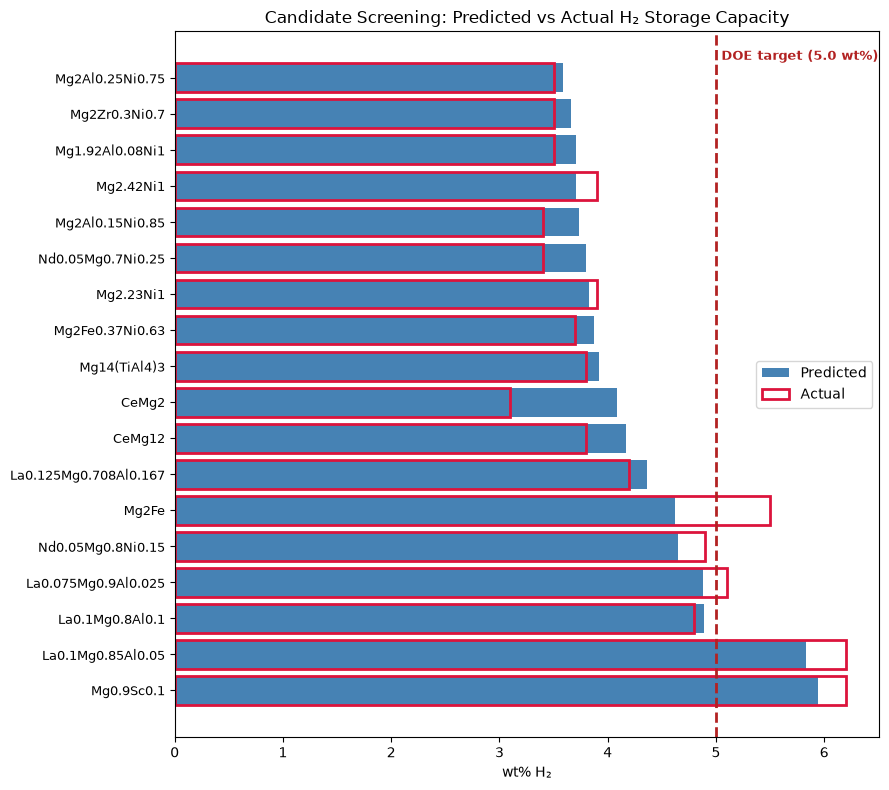

In [12]:
fig, ax = plt.subplots(figsize=(9, 8))
y_pos = range(len(candidates_all))

ax.barh(y_pos, candidates_all['wt%_predicted'], color='steelblue', label='Predicted')
ax.barh(y_pos, candidates_all['wt%_actual'], color='none', edgecolor='crimson', linewidth=2, label='Actual')
ax.axvline(x=5.0, color='firebrick', linestyle='--', linewidth=2)
ax.text(5.05, len(candidates_all) - 0.5, 'DOE target (5.0 wt%)', color='firebrick', fontsize=9, fontweight='bold')
ax.set_yticks(y_pos)
ax.set_yticklabels(candidates_all['Composition_Formula'], fontsize=9)
ax.set_xlabel('wt% H₂')
ax.set_title('Candidate Screening: Predicted vs Actual H₂ Storage Capacity')
ax.legend()
plt.tight_layout()
plt.savefig('../results/candidates_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## Screening Results: Interpretation

### Test Set Screening

The model identifies 2 candidates above 3.5 wt% on the held-out test set (112 compounds unseen during training): Mg2Fe0.37Ni0.63 (predicted 3.87, actual 3.7) and Mg1.92Al0.08Ni1 (predicted 3.70, actual 3.5). No compounds in the test set exceed 5.0 wt%, reflecting the distribution of the test split rather than a model limitation.

### Exploratory Screening: Full Dataset

Applying the model to the full dataset (741 compounds, including training and validation, not a blind screening) identifies 18 candidates above 3.5 wt%, of which 2 exceed the DOE target of 5.0 wt%: Mg0.9Sc0.1 and La0.1Mg0.85Al0.05 (both with actual wt% = 6.2%).

A slight asymmetry is observed: the model tends to overestimate wt% for compounds below ~4 wt%, and to underestimate above ~4 wt%. This is consistent with the known behaviour of Random Forest regressors, which compress extreme values towards the mean.

All 18 candidates are Mg-based compounds, consistent with the SHAP analysis from notebook 04, where Material_Class_Mg was the most impactful feature.

### Future Work

- **Notebook 06**: generate a list of novel candidate compounds not present in the dataset, compute features from experimental data sources, and apply the Dataset A model for blind screening
- **Dataset B expansion**: collect additional experimental desorption temperature data to build a reliable predictive model, enabling combined screening for high wt% and near-RT desorption: the ultimate goal of this project

